In [1]:
import pandas as pd
df_raw=pd.read_csv("final_dataset.csv")

In [2]:
df=df_raw[[
    "avg_d_kbps",
    "avg_u_kbps",
    "avg_lat_ms",
    "tests",
    "devices",
    "lat",
    "lon"
]]

In [3]:
df["download_mbps"] = df["avg_d_kbps"] / 1000
df["upload_mbps"] = df["avg_u_kbps"] / 1000
df["latency_ms"] = df["avg_lat_ms"]


In [4]:
df.shape

(556608, 10)

In [5]:
df = df.drop(columns=["avg_d_kbps", "avg_u_kbps", "avg_lat_ms"])

In [6]:
df = df[df["download_mbps"] > 0]
df = df[df["latency_ms"] > 0]
df = df[df["tests"] > 1]     # relaxed
df = df[df["devices"] > 0]   # relaxed

In [7]:
df.shape

(325072, 7)

In [8]:
print(df.head())
print(df.columns)

   tests  devices        lat        lon  download_mbps  upload_mbps  \
0      3        2  33.461234  72.869568         30.917        2.370   
1      3        1  24.849058  88.063660        333.429        9.502   
4     11       10  18.695684  78.121033        208.317       26.433   
5     13        6  22.738190  75.819397         49.189       10.681   
7      8        1  23.087312  95.413513          1.013        1.639   

   latency_ms  
0          18  
1          27  
4          33  
5          24  
7          67  
Index(['tests', 'devices', 'lat', 'lon', 'download_mbps', 'upload_mbps',
       'latency_ms'],
      dtype='str')


In [9]:
def classify_network(download):
    if download > 20:
        return 2
    elif download > 8:
        return 1
    else:
        return 0

df["network_quality"] = df["download_mbps"].apply(classify_network)


# 2️⃣ FEATURE ENGINEERING
df["density"] = df["tests"] / (df["devices"] + 1)
df["interaction_1"] = df["upload_mbps"] * df["density"]
df["interaction_2"] = df["tests"] / (df["latency_ms"] + 1)
df["latency_inv"] = 1 / (df["latency_ms"] + 1)


In [10]:
print(df.head())
print(df.columns)

   tests  devices        lat        lon  download_mbps  upload_mbps  \
0      3        2  33.461234  72.869568         30.917        2.370   
1      3        1  24.849058  88.063660        333.429        9.502   
4     11       10  18.695684  78.121033        208.317       26.433   
5     13        6  22.738190  75.819397         49.189       10.681   
7      8        1  23.087312  95.413513          1.013        1.639   

   latency_ms  network_quality   density  interaction_1  interaction_2  \
0          18                2  1.000000       2.370000       0.157895   
1          27                2  1.500000      14.253000       0.107143   
4          33                2  1.000000      26.433000       0.323529   
5          24                2  1.857143      19.836143       0.520000   
7          67                0  4.000000       6.556000       0.117647   

   latency_inv  
0     0.052632  
1     0.035714  
4     0.029412  
5     0.040000  
7     0.014706  
Index(['tests', 'devices',

In [11]:
X = df[[
    "upload_mbps",
    "latency_ms",
    "latency_inv",
    "tests",
    "devices",
    "density",
    "interaction_1",
    "interaction_2",
    "lat",
    "lon"
]]

y = df["network_quality"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2])

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

sample_weights = np.array([class_weights[y] for y in y_train])

In [14]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,              # ↓ reduce overfitting
    learning_rate=0.05,       # ↓ smoother learning
    subsample=0.8,
    colsample_bytree=0.7,     # 👈 forces feature diversity
    gamma=1,                  # 👈 penalize easy splits
    reg_alpha=0.5,            # 👈 L1 regularization
    reg_lambda=1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1
)

In [15]:
model.fit(X_train, y_train, sample_weight=sample_weights)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.32      0.68      0.44      4246
           1       0.26      0.51      0.35      7927
           2       0.97      0.74      0.84     52842

    accuracy                           0.71     65015
   macro avg       0.52      0.65      0.54     65015
weighted avg       0.84      0.71      0.75     65015



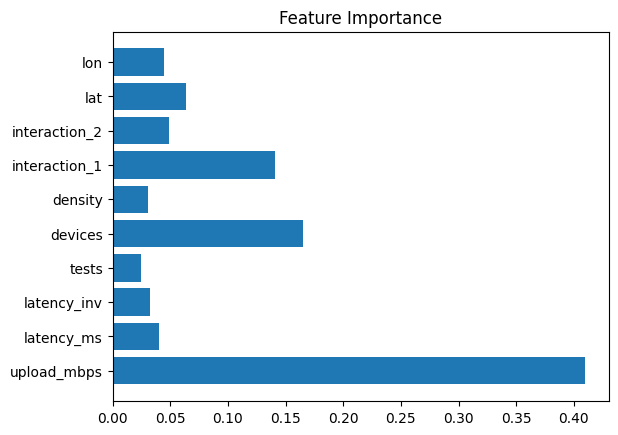

In [18]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [19]:
import joblib

joblib.dump(model, "xgb_model.pkl")

['xgb_model.pkl']